In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [5]:
np.random.seed(42)

DATA=pd.DataFrame({
    "hours_studied":np.random.randint(1,10,50),
    "attendence":np.random.randint(50,100,50),
})
DATA.head()

,hours_studied,attendence
0,7,53
1,4,51
2,8,55
3,5,91
4,7,53


In [7]:
x=DATA[["hours_studied","attendence"]]

model=KMeans(n_clusters=3,random_state=42,n_init=10)
DATA["cluster"]=model.fit_predict(x)

In [9]:
score=silhouette_score(x,DATA["cluster"])
print("silhouette score",score)



silhouette score 0.5276411515754762


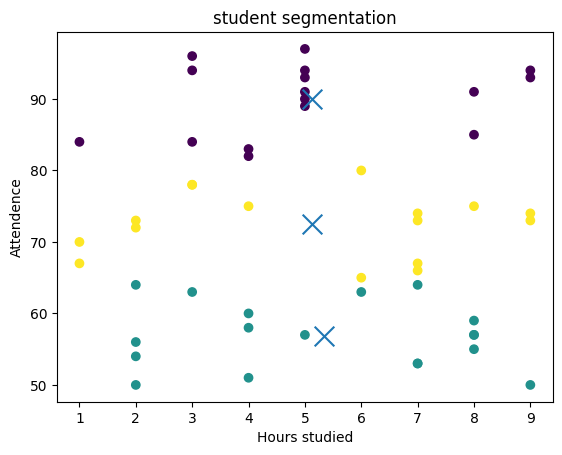

In [10]:
plt.scatter(DATA["hours_studied"],DATA["attendence"],c=DATA["cluster"])

centers=model.cluster_centers_
plt.scatter(centers[:,0],centers[:,1],marker='x',s=200)

plt.xlabel("Hours studied")
plt.ylabel("Attendence")
plt.title("student segmentation")
plt.show()

In [12]:
# example:New student
# hours_studied=6,attendance=80

new_student=[[6,80]]

predicted_cluster=model.predict(new_student)

print("new student belongs to cluster",predicted_cluster[0])

new student belongs to cluster 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [14]:
DATA.groupby("cluster").mean()

,hours_studied,attendence
cluster,,
0,5.125000,90.000000
1,5.333333,56.888889
2,5.125000,72.500000
